In [63]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objs as go

In [64]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

tesla_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [68]:
url_tesla = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) \
                   AppleWebKit/537.36 (KHTML, like Gecko) \
                   Chrome/90.0.4430.93 Safari/537.36"
}

response = requests.get(url_tesla, headers=headers)
soup_tesla = BeautifulSoup(response.text, "html.parser")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
for row in soup_tesla.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) == 2:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip().replace("$", "").replace(",", "")
        if revenue:
            tesla_revenue = pd.concat(
                [tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
                ignore_index=True
            )

tesla_revenue.tail()

,Date,Revenue
73,2010-09-30,31
74,2010-06-30,28
75,2010-03-31,21
76,2009-09-30,46
77,2009-06-30,27


In [70]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)

gme_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [71]:
url_gme = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) \
                   AppleWebKit/537.36 (KHTML, like Gecko) \
                   Chrome/90.0.4430.93 Safari/537.36"
}
response = requests.get(url_gme, headers=headers)
soup_gme = BeautifulSoup(response.text, "html.parser")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in soup_gme.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) == 2:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip().replace("$", "").replace(",", "")
        if revenue:
            gme_revenue = pd.concat([
                gme_revenue,
                pd.DataFrame({"Date": [date], "Revenue": [revenue]})
            ], ignore_index=True)

gme_revenue.tail(5)

,Date,Revenue
77,2010-01-31,3524
78,2009-10-31,1835
79,2009-07-31,1739
80,2009-04-30,1981
81,2009-01-31,3492


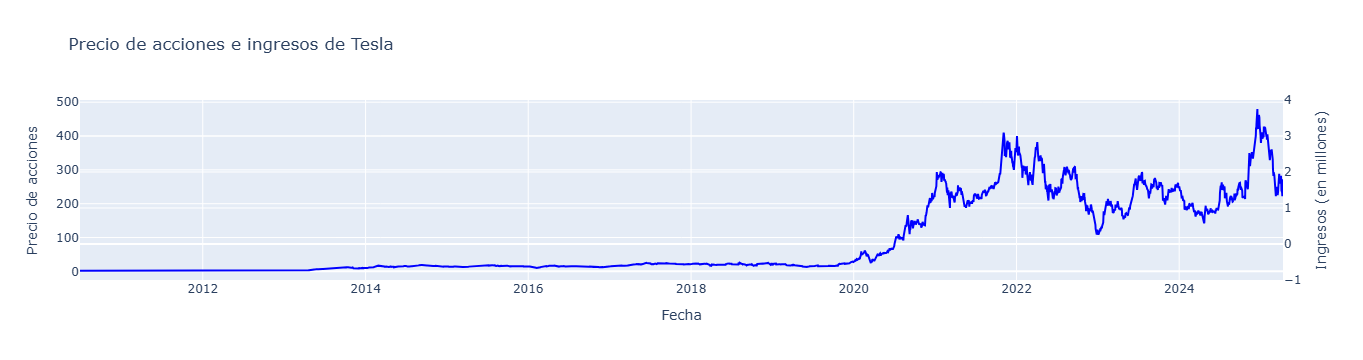

In [57]:
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])
tesla_data["Date"] = pd.to_datetime(tesla_data["Date"])

fig_tsla = go.Figure()

fig_tsla.add_trace(go.Scatter(
    x=tesla_data["Date"], y=tesla_data["Close"],
    name="Precio de las acciones (TSLA)",
    line=dict(color='blue')
))

fig_tsla.add_trace(go.Scatter(
    x=tesla_revenue["Date"], y=tesla_revenue["Revenue"].astype(float),
    name="Ingresos (TSLA)",
    line=dict(color='green'),
    yaxis="y2"
))

fig_tsla.update_layout(
    title="Precio de acciones e ingresos de Tesla",
    xaxis_title="Fecha",
    yaxis=dict(title="Precio de acciones"),
    yaxis2=dict(title="Ingresos (en millones)", overlaying="y", side="right"),
    legend=dict(x=0.1, y=1.1, orientation="h")
)

fig_tsla.show()


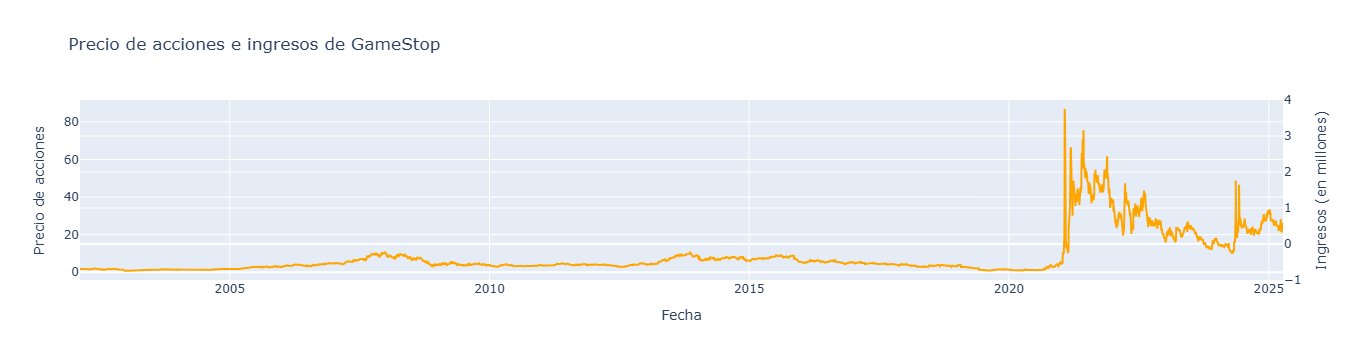

In [58]:
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
gme_data["Date"] = pd.to_datetime(gme_data["Date"])

fig_gme = go.Figure()

fig_gme.add_trace(go.Scatter(
    x=gme_data["Date"], y=gme_data["Close"],
    name="Precio de las acciones (GME)",
    line=dict(color='orange')
))

fig_gme.add_trace(go.Scatter(
    x=gme_revenue["Date"], y=gme_revenue["Revenue"].astype(float),
    name="Ingresos (GME)",
    line=dict(color='red'),
    yaxis="y2"
))

fig_gme.update_layout(
    title="Precio de acciones e ingresos de GameStop",
    xaxis_title="Fecha",
    yaxis=dict(title="Precio de acciones"),
    yaxis2=dict(title="Ingresos (en millones)", overlaying="y", side="right"),
    legend=dict(x=0.1, y=1.1, orientation="h")
)

fig_gme.show()
